In [63]:
import pandas as pd
df=pd.read_csv('data/income.csv')
df

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000
5,Gautam,39,155000
6,David,41,160000
7,Andrea,38,162000
8,Brad,36,156000
9,Angelina,35,130000


In [64]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Income($)')

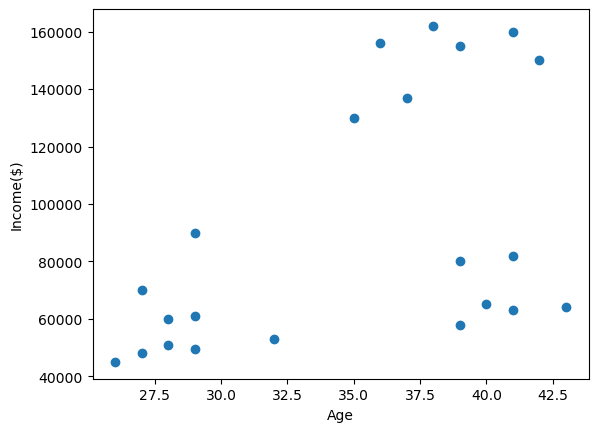

In [65]:
plt.scatter(df['Age'],df['Income($)'])
plt.xlabel('Age')
plt.ylabel('Income($)')

In [66]:
km=KMeans(n_clusters=3)

In [67]:
y=km.fit_predict(df[['Age']],df[['Income($)']])
y

array([1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2],
      dtype=int32)

In [68]:
df['cluster']=y
df

,Name,Age,Income($),cluster
0,Rob,27,70000,1
1,Michael,29,90000,1
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0
5,Gautam,39,155000,2
6,David,41,160000,0
7,Andrea,38,162000,2
8,Brad,36,156000,2
9,Angelina,35,130000,2


In [69]:
df1=df[df['cluster']==0]
df2=df[df['cluster']==1]
df3=df[df['cluster']==2]
df1
df2
df3

,Name,Age,Income($),cluster
5,Gautam,39,155000,2
7,Andrea,38,162000,2
8,Brad,36,156000,2
9,Angelina,35,130000,2
10,Donald,37,137000,2
19,Alia,39,80000,2
21,Abdul,39,58000,2


/var/folders/3q/hxkw63kn46904kg5_z_5cbzr0000gn/T/ipykernel_6533/1600819626.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


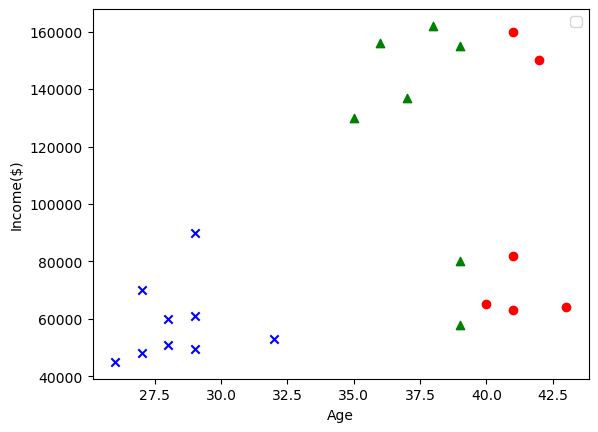

In [70]:
plt.scatter(df1['Age'],df1['Income($)'],marker='o',color='red')
plt.scatter(df2['Age'],df2['Income($)'],marker='x',color='blue')
plt.scatter(df3['Age'],df3['Income($)'],marker='^',color='green')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.legend()

Preprocessing using MInMax scaler for better clustering

In [71]:
scaler=MinMaxScaler()

In [72]:
scaler.fit(df[['Age']])
df.Age=scaler.transform(df[['Age']])

In [73]:
scaler.fit(df[['Income($)']])
df['Income($)']=scaler.transform(df[['Income($)']])

In [88]:
df


,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,3
1,Michael,0.176471,0.384615,3
2,Mohan,0.176471,0.136752,3
3,Ismail,0.117647,0.128205,3
4,Kory,0.941176,0.897436,0
5,Gautam,0.764706,0.940171,0
6,David,0.882353,0.982906,0
7,Andrea,0.705882,1.000000,0
8,Brad,0.588235,0.948718,0
9,Angelina,0.529412,0.726496,0


In [89]:
km1=KMeans(n_clusters=3)
df['cluster']=km1.fit_predict(df[['Age','Income($)']])
df

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Gautam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,1


In [108]:
df10=df[df['cluster']==0]
df20=df[df['cluster']==1]
df30=df[df['cluster']==2]

km1.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

Text(0, 0.5, 'Income($)')

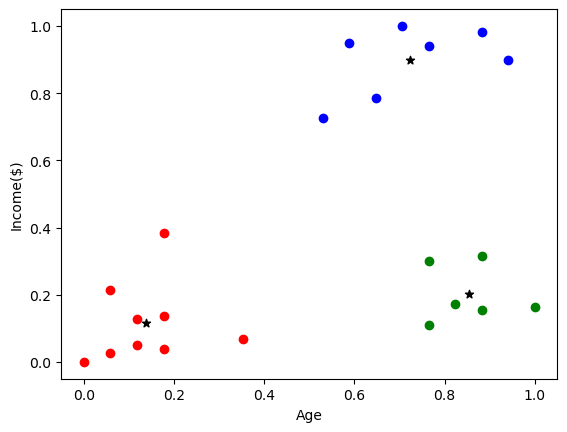

In [109]:
plt.scatter(df10['Age'], df10['Income($)'],color='red')
plt.scatter(df20['Age'], df20['Income($)'],color='blue')
plt.scatter(df30['Age'], df30['Income($)'],color='green')
plt.scatter(km1.cluster_centers_[:,0],km1.cluster_centers_[:,1],marker='*',color='black')
plt.xlabel('Age')
plt.ylabel('Income($)')



Elbow method for finding K

In [115]:
sse=[]
for k in range (1,10):
    km =KMeans(n_clusters=k)
    model=km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)


In [116]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553096,
 0.42015522057314425,
 0.2621792762345213,
 0.24591705034877784,
 0.21628098847751795,
 0.1497013699361909,
 0.11866260536520497]

Text(0, 0.5, 'sse')

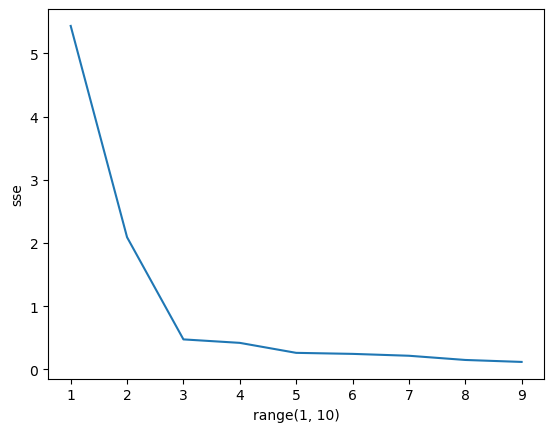

In [119]:
plt.plot(range(1,10),sse)
plt.xlabel(range(1,10))
plt.ylabel('sse')